# 02 — Choosing a model, and choosing a threshold

Two decisions, and the second one is the one that decides whether the project pays
for itself.

The models are trained by `polaris.training`, not here. This notebook loads what
the platform produced and compares it — so the numbers below are the numbers in
the registry, not a parallel experiment that happens to agree with them.

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [2]:
from polaris.config import get_settings
from polaris.registry.store import list_versions, segment_metrics

settings = get_settings()
versions = list_versions("churn-60d", settings)
pd.DataFrame([
    {
        "version": v.version,
        "stage": v.stage,
        "algorithm": v.metrics.get("algorithm"),
        "test_pr_auc": v.pr_auc,
        "test_roc_auc": v.metrics.get("test_roc_auc"),
        "brier": v.metrics.get("test_brier"),
        "lift@100": v.metrics.get("test_lift_at_100"),
        "threshold": v.decision_threshold,
    }
    for v in versions
]).round(4)

,version,stage,algorithm,test_pr_auc,test_roc_auc,brier,lift@100,threshold
0,2,production,gradient_boosting,0.3155,0.8856,0.0236,28.3558,0.1162
1,1,archived,logistic,0.2856,0.8859,0.0242,23.2313,0.0935


### The average hides the thing that matters

Gradient boosting wins overall. Split by segment and the picture is less
comfortable — and this is exactly what the promotion gate checks before letting a
challenger through.

In [3]:
rows = []
for v in versions:
    if v.stage == "rejected":
        continue
    for segment, (value, positives) in segment_metrics("churn-60d", v.version, settings=settings).items():
        rows.append({"version": v.version, "algorithm": v.metrics.get("algorithm"),
                     "segment": segment, "pr_auc": round(value, 4), "churns": positives})
pd.DataFrame(rows).pivot_table(index=["segment"], columns="version", values="pr_auc")

version,1,2
segment,,
enterprise,0.2686,0.2548
mid_market,0.2629,0.2392
overall,0.2856,0.3155
smb,0.3012,0.3487


A segment with a handful of churns cannot support a decision; the gate reports
those as *not evaluable* rather than comparing two noisy numbers. That rule is why
enterprise does not block a promotion here — and why the fix is more data, not a
more permissive threshold.

In [4]:
from polaris.data import build_dataset
from polaris.registry.store import get_production
from polaris.training.evaluate import calibration_table

dataset = build_dataset(settings)
production = get_production("churn-60d", settings)
payload = production.load()
model = payload["model"]

probabilities = model.predict_proba(dataset.test.X)[:, 1]
calibration = calibration_table(dataset.test.y.to_numpy(), probabilities)
calibration

,bucket,n,mean_predicted,observed,gap
0,1,2926,0.00003,0.00000,-0.00003
1,2,3281,0.00059,0.00000,-0.00059
2,3,2006,0.00165,0.00150,-0.00015
3,4,2210,0.00339,0.00814,0.00476
4,5,2100,0.00709,0.01095,0.00387
5,6,2083,0.01257,0.01680,0.00424
6,7,2085,0.02060,0.02878,0.00818
7,8,2093,0.04164,0.05208,0.01044
8,9,2090,0.17212,0.17368,0.00156


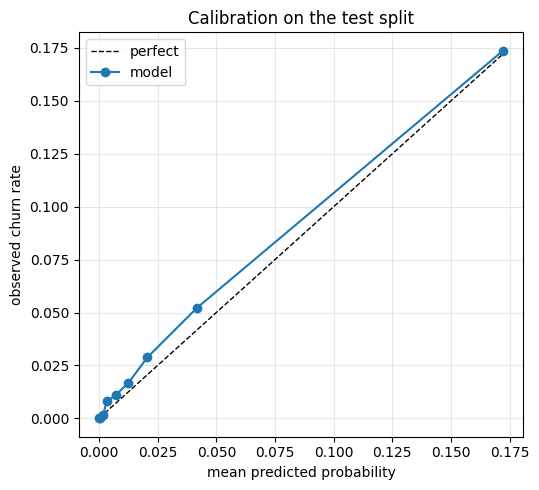

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, calibration.mean_predicted.max()], [0, calibration.mean_predicted.max()],
        "k--", lw=1, label="perfect")
ax.plot(calibration.mean_predicted, calibration.observed, "o-", label="model")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed churn rate")
ax.set_title("Calibration on the test split"); ax.legend()
plt.tight_layout(); plt.show()

Calibration matters here for a specific reason: the threshold is an
expected-value calculation, and an expected value computed from a score that does
not mean what it says is arithmetic on a fiction.

### The threshold is an economic question

Acting costs money whether or not the account was leaving. With a 9 000 EUR
account, a 350 EUR retention play and a 30% success rate, a true positive is worth
2 350 EUR and a false positive costs 350.

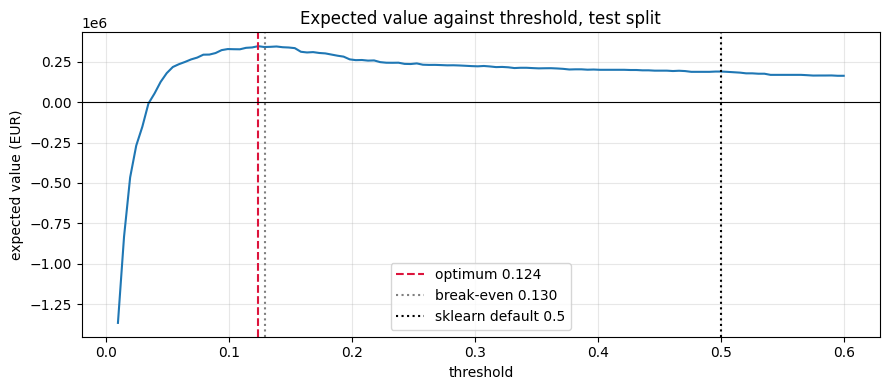

{'threshold': 0.12369, 'expected_value_eur': 347650.0, 'expected_value_per_1000_accounts': 16654.69, 'flagged': 1051.0, 'true_positives': 265.0, 'false_positives': 786.0, 'precision': np.float64(0.2521), 'recall': 0.4337}
{'call_nobody_eur': 0.0, 'call_everyone_eur': -5656200.0, 'call_everyone_per_1000': -270968.66915780393}


In [6]:
from polaris.economics import Economics, baseline_values, choose_threshold, expected_value

economics = Economics.from_settings(settings)
y_test = dataset.test.y.to_numpy()

grid = np.linspace(0.01, 0.6, 120)
values = [expected_value(y_test, probabilities, t, economics) for t in grid]
best = choose_threshold(y_test, probabilities, economics)

fig, ax = plt.subplots()
ax.plot(grid, values)
ax.axvline(best.threshold, color="crimson", ls="--", label=f"optimum {best.threshold:.3f}")
ax.axvline(economics.break_even_probability, color="grey", ls=":",
           label=f"break-even {economics.break_even_probability:.3f}")
ax.axvline(0.5, color="black", ls=":", label="sklearn default 0.5")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("threshold"); ax.set_ylabel("expected value (EUR)")
ax.set_title("Expected value against threshold, test split"); ax.legend()
plt.tight_layout(); plt.show()

print(best.as_dict())
print(baseline_values(y_test, economics))

Three things this chart says at once:

* the optimum is far below 0.5 — using the default threshold would leave most of
  the value unclaimed;
* it is above the break-even probability, because the score distribution, not only
  the arithmetic, decides where the optimum sits;
* calling everybody is worth a large negative number. A model is not competing
  against nothing; it is competing against the cheapest sensible alternative.